In [1]:
import os 

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import max_sum

load_dotenv()  # take environment variables from .env.

# Below bckends allow testing of circuits without actually submitting a job to IBMq
# backend_aer = AerSimulator()
# fake_manila = FakeManilaV2() # TODO delete if backend instatiation works

QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token=os.environ.get("ibmq_api_key"),
    set_as_default=True,
    # Use `overwrite=True` if you're updating your token.
    overwrite=True,
)
 
# Load saved credentials
service = QiskitRuntimeService()

# Choose your backend, you should always test your circuit on a simulator first.
# backend = FakeManilaV2()
backend = AerSimulator()

# This backend will send a job to the IBM Job queue which is the least busy
# backend = service.least_busy(operational=True, simulator=False) 

# sets optimization level
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)


# Job preperation
We are preparing two jobs:

## Plotting the correlation function
The first job calculates the correlation of the two qubits through a range of angles and plots the result so we can compare it to the predicted correlation function. We call this `correlation_function_job`.

## Measuring the CHSH sum
The second job chooses 4 specific angles to take measurements with which to calculate the CHSH sum and thus invalidate the CHSH inequality. We call this `chsh_job`.

We choose the angles which will maximise the sum by optimising over the theoretical correlation function in `max_sum.py`, the angles are then hard coded below.

In [2]:
# We use a range of theta values for plotting the correlation function
start_theta = 0;
end_theta = np.pi;
num_steps = 10;
num_shots = 1024; # Number of repeat experiments

# List of theta values to rotate qubits before measurement
theta_vals = np.linspace(start_theta, end_theta, num_steps) # start_theta to end_theta  in num_steps steps
# print(theta_vals)

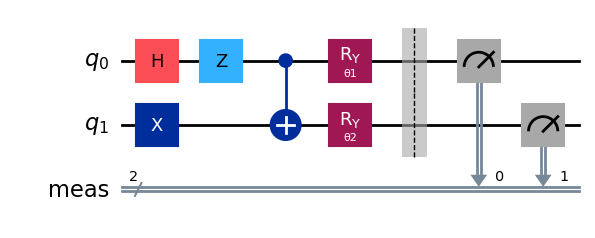

In [3]:

# We introduce the parameters to rotate the qubits through an angle θ.
theta1 = Parameter('θ1')
theta2 = Parameter('θ2')
correlation_function_job = np.array([theta_vals,theta_vals[::-1]]).T

# The angles for calculating the chsh sum:
# These are calculated using max_sum.py to maximise the chsh sum
theta_A = -0.09354
theta_B = -2.450
theta_A_prime = 1.477
theta_B_prime = 2.263
chsh_job = np.array(
    [
    [theta_A, theta_B],
    [theta_A_prime, theta_B],
    [theta_A, theta_B_prime],
    [theta_A_prime, theta_B_prime],
    ]
)



# Define the circuit with 2 qubits, a classical register for measurements is included by default
par_qc_ent_2 = QuantumCircuit(2)

# define the circuit
par_qc_ent_2.h(0) # Hadamard gate H(q) acts on qubit q;
par_qc_ent_2.x(1) # X Pauli gate
par_qc_ent_2.z(0) # Z Pauli gate 
par_qc_ent_2.cx(0,1) # CNOT gates. This one has 0 as control, 1 as target
par_qc_ent_2.ry(theta1, 0) # rotation gate, Y axis; angle = theta1, qubit is 0
par_qc_ent_2.ry(theta2, 1) # rotation gate, Y axis; angle = theta2, qubit is 0

# Take a measurements on both qubits
par_qc_ent_2.measure_all()

# Render the circuit
par_qc_ent_2.draw('mpl')

In [4]:
# Prepare the Job
isa_circuits_2 =  transpile(par_qc_ent_2,backend) # converts circuit to equivalent but more efficient circuit depending on the backend
sampler = Sampler(backend)
job_2 = sampler.run([(isa_circuits_2, correlation_function_job, num_shots)])
job_3 = sampler.run([(isa_circuits_2, chsh_job, num_shots)])
result_2 = job_2.result()
result_3 = job_3.result()

# JOB ID: you may need the job ID for later. If the job takes too long you can paste the job id into the cell below
print(f"job_2.job_id(): {job_2.job_id()}")
print(f"job_3.job_id(): {job_3.job_id()}")


job_2.job_id(): b386ebd1-a070-4bd4-80a2-10d4a7413ef2
job_3.job_id(): 87182275-2b88-4c57-91a3-80ed7beb21c1


[-3.14159265 -2.44346095 -1.74532925 -1.04719755 -0.34906585  0.34906585
  1.04719755  1.74532925  2.44346095  3.14159265]
[ 1.          0.74804688  0.19335938 -0.5        -0.94921875 -0.92578125
 -0.51171875  0.1875      0.75        1.        ]
corr uncertainty 0.03125


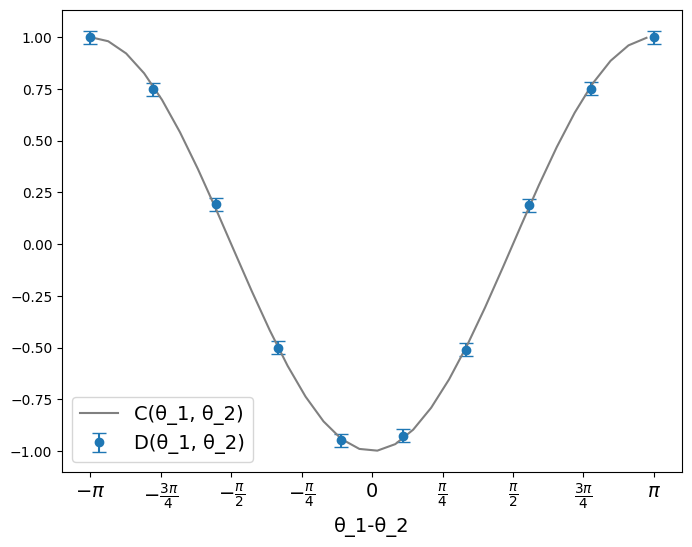

In [5]:
# CELL 8:
# plots the results. this is useful to sense check the output
# you should use the raw data to plot/tabulate your own data 

# If navigated away from the IBM site during your run, you can retrieve the results here.
# Paste job number given above into this cell.
job = service.job('czhmn34aejkg008cjm3g')

data_result_2 = result_2[0].data
bits_2 = data_result_2.meas
#print("array:\n", bits.array)


#sum counts over number of shots
p00s_2 = np.sum(bits_2.array == 0, axis=1) 
p01s_2 = np.sum(bits_2.array == 1, axis=1) 
p10s_2 = np.sum(bits_2.array == 2, axis=1) 
p11s_2 = np.sum(bits_2.array == 3, axis=1) 

# Plot the correlation function
# plt.rcParams['text.usetex'] = True
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

# below the correlation function is calculated point by point.
corr_2 = list(map(lambda a2, b2, c2, d2: (a2 + d2 -c2 -b2)/bits_2.num_shots, p00s_2, p01s_2, p10s_2, p11s_2))
corr_uncertainty = 1/np.sqrt(bits_2.num_shots)
yerr = np.full_like(corr_2, corr_uncertainty)

x=theta_vals - theta_vals[::-1]
print(x)

corr_2_flat = np.array([corr[0] for corr in corr_2])
print(corr_2_flat)
print(f"corr uncertainty {corr_uncertainty}")

# make the plot and labels etc.
# ax.plot(theta_vals-theta_vals[::-1], corr_2, 'o', label='D(θ_1, θ_2)')
ax.set_xticks([i * np.pi / 4 for i in range(-4,5)])
ax.errorbar(x, corr_2_flat, yerr=corr_uncertainty, fmt='o', label='D(θ_1, θ_2)', capsize=5)
# ax.errorbar(theta_vals - theta_vals[::-1], corr_2, yerr=corr_uncertainty, fmt='o', label='D(θ_1, θ_2)', capsize=5)


# need to plot the theoretical correlation function too.
x0_range = np.arange(start_theta, end_theta, 0.1)
x1_range = np.arange(end_theta,start_theta, -0.1)
cos_func= -np.cos(x0_range-x1_range)
ax.plot(x0_range-x1_range, cos_func, color='grey', label='C(θ_1, θ_2)')


ax.set_xticklabels([
        r'$-\pi$',
        r'$-\frac{3\pi}{4}$',
        r'$-\frac{\pi}{2}$',
        r'$-\frac{\pi}{4}$',
        '0',
        r'$\frac{\pi}{4}$',
        r'$\frac{\pi}{2}$',
        r'$\frac{3\pi}{4}$',
        r'$\pi$'
    ],
    fontsize=14)
ax.set_xlabel('θ_1-θ_2', fontsize=14)
ax.legend(fontsize=14);
# plt.gca().set_aspect( 0.999 )


## We use max_sum.py to find the angles that maximise the CHSH sum
$$ \theta_1 = -0.09354 $$
$$ \theta_2 = -2.450 $$
$$ \theta_1' = 1.477 $$
$$ \theta_2' = 2.263 $$

In [6]:
# Calculate CHSH sum using chsh_job
# Paste job number given above into this cell.
job = service.job('czhmn3maejkg008cjm4g')

data_result_3 = result_3[0].data
bits_3 = data_result_3.meas
# print("array:\n", bits.array)


#sum counts over number of shots
p00s_3 = np.sum(bits_3.array == 0, axis=1) 
p01s_3 = np.sum(bits_3.array == 1, axis=1) 
p10s_3 = np.sum(bits_3.array == 2, axis=1) 
p11s_3 = np.sum(bits_3.array == 3, axis=1)

# Calculate the CHSH sum

# below the correlation function is calculated point by point.
# check the signs! 
# remember: correlation is (N(agree) - N(disagree))/N(total).
# outputs 00 and 11 agree, 10 and 01 disagree.
# check division by N(total).
# corr_3 = list(map(lambda a2, b2, c2, d2: (a2 + d2 -c2 -b2)/bits_3.num_shots, p00s_3, p01s_3, p10s_3, p11s_3))
def calc_corrs(p00s_3, p01s_3, p10s_3, p11s_3, num_shots):
    corrs = []
    for i in range(len(p11s_3)):
        corrs.append((p00s_3[i][0] + p11s_3[i][0] - p01s_3[i][0] - p10s_3[i][0])/num_shots)
    return np.array(corrs)

corr_3 = calc_corrs(p00s_3, p01s_3, p10s_3, p11s_3, bits_3.num_shots)
corr_uncertainty = 1/np.sqrt(bits_3.num_shots)

# flat_corr = [x[0] for x in corr]
print(f"corr_3: {corr_3}")


def chsh_sum(corr_vals: list)->float:
    """Calculate the absolute chsh sum from the correlation values of 4 readings.
    This requires that the values are in the correct order.

    Args:
        corr_vals (list): A list of corr values 
        [D(theta_A, theta_B), D(theta_A_prime, theta_B), D(theta_A, theta_B_prime), D(theta_A_prime, theta_B_prime)]

    Returns:
        float: The CHSH sum.
    """
    return np.abs(corr_vals[0] + corr_vals[1] + corr_vals[2] - corr_vals[3])



chsh_sum_abs = chsh_sum(corr_3)
chsh_uncertainty = 2/bits_3.num_shots
print(f"The chsh_sum_abs is: {chsh_sum_abs} +- {chsh_uncertainty}")

expected_value = max_sum.theoretical_chsh_sum(theta_A, theta_B, theta_A_prime, theta_B_prime)
print(f"expected value according to C(theta_A, theta_B): {expected_value}")

corr_3: [ 0.734375    0.66015625  0.71289062 -0.67773438]
The chsh_sum_abs is: 2.78515625 +- 0.001953125
expected value according to C(theta_A, theta_B): 2.828426929545325
